# Microstrip Arrangment Potential Distribution

## Initialization

In [1]:
# import required libraries
########################################################################################
# calculations
import time
import os
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# reload
from importlib import reload
from typing import *

# import custom files
#############################################################################################
# import helper functions
import helper_functions as F
# import custom environmnet
from MicroStripArrangementEnv import MicroStripArrangementEnv as msaEnv
reload(F)

# import RL
###############################################################################################
# import stable baselines 3 algorithm
from stable_baselines3 import SAC,TD3
# import stable baselines 3 functions
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv #, SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
# from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
# from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

# import pytorch for setting policy kwargs
import torch as th

## File Locations

In [2]:
# create folders to save models and log files
models_dir_root = "training/models"
logdir_root = "training/logs"
imgdir_root = "training/images"
if not os.path.exists(models_dir_root):
    os.makedirs(models_dir_root)
    
if not os.path.exists(logdir_root):
    os.makedirs(logdir_root)

if not os.path.exists(imgdir_root):
    os.makedirs(imgdir_root)

In [3]:
# env=msaEnv(V0=1,hw_arra=0.002,ht_arra=0.002,ht_subs=0.00079,hw_micrstr=0.0002,ht_micrstr=0,er_1=1,er_2=2.2,num_fs=20,num_pts=20)
# from stable_baselines3.common.env_checker import check_env
# check_env(env, warn=True)

## Train

### Callback

In [4]:
class IntermediatePredictionCallback(BaseCallback):
    """
    A custom callback that derives from ``BaseCallback``
    Does intermediate prediction and generates images

    """
    def __init__(self, env,output_interval:int,imgdir:str,x_true:np.ndarray,y_true:np.ndarray,case:str):
        super(IntermediatePredictionCallback, self).__init__()
        self.env = env
        self.output_interval = output_interval
        self.imgdir = imgdir
        self.x_true = x_true
        self.y_true = y_true
        self.case = case
        self.action_df = {'Action':[],
                          'Timestep':[]}

    def _on_step(self):
        # Check if the current timestep is a multiple of the output interval
        if self.num_timesteps % self.output_interval == 0:
            # print('Within Callback')
            # Function to predict and generate output images
            action = F.do_prediction_intermediate_stage(self.model,self.env,self.x_true,self.y_true,self.imgdir,self.case,self.num_timesteps) 
            # print('End of Callback')
            self.action_df['Action'].append(action)
            self.action_df['Timestep'].append(self.num_timesteps)
            (pd.DataFrame(self.action_df)).to_csv(f"{self.imgdir}/action.csv")
            

In [5]:
timesteps=50_000

### Case D

In [2]:
# hw_micrstr = 0.05e-3
# # read true values 
# df_D = pd.read_csv('NominalGPtsCaseDCase2_1.csv')
# df_D = df_D[df_D['g_ptsx'] >= hw_micrstr]
# df_D = df_D.drop_duplicates(['g_ptsx'])

# x_true = np.array(df_D['g_ptsx']) 
# y_true = np.array(df_D['g_ptsy'])

# x_true = np.insert(x_true,0,0)
# y_true = np.insert(y_true,0,1)
# y_true[-1] = 0

df_D = pd.read_csv('Yamashita_NominalGPtsCaseDCase2_1.csv')

x_true = np.array(df_D['g_ptsx']) 
y_true = np.array(df_D['g_ptsy'])

#### TD3

In [7]:
# env setup
################################################################################################################################################
# setting up the MSA env with number of fs_coeff = 20
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=20,num_pts=10)

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=10)

# model setup
####################################################################################################################################################

# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_D','TD3')
logdir = os.path.join(logdir_root,'Case_D','TD3')
imgdir = os.path.join(imgdir_root,'Case_D','TD3')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[400, 300])

action_noise = OrnsteinUhlenbeckActionNoise(mean=np.zeros(env_D.action_space.shape), sigma=float(0.5) * np.ones(env_D.action_space.shape))

hyperparams = {
    'gamma': 0.98,
    'buffer_size': 200000, 
    'learning_starts': 1_000,
    'gradient_steps': 1,
    'batch_size': 256,
}

# set the total steps to be taken during model learning
TIMESTEPS = timesteps # one hundred thousand timesteps

model = TD3("MlpPolicy", 
             env_D,  
             verbose=0, 
             action_noise=action_noise,
             policy_kwargs=policy_kwargs,
             tensorboard_log=os.path.join(logdir,'TD3'),
             **hyperparams)

print('training...........')
start_time = time.time()
model.learn(total_timesteps=TIMESTEPS,
            log_interval=4,
            reset_num_timesteps=True, 
            tb_log_name='Case_D',
            progress_bar=True,
            callback=IntermediatePredictionCallback(env_D,5_000,imgdir,x_true,y_true,'Case_D'))
end_time = time.time()

training_time = end_time - start_time
model.save(f"{models_dir}/{'Case_D'}_{'TD3'}_MSAEnv")

Output()

training...........


#### SAC

In [8]:
# # setting up the MSA env with number of fs_coeff = 20
# env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=20,num_pts=10)

# # set a different environment for evaluation
# eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=10)

In [9]:
# # Specify directories
# #################################################################################################
# models_dir = os.path.join(models_dir_root,'Case_D','SAC')
# logdir = os.path.join(logdir_root,'Case_D','SAC')
# imgdir = os.path.join(imgdir_root,'Case_D','SAC')

# for dir in [models_dir,logdir,imgdir]:
#     if not os.path.exists(dir):
#         os.makedirs(dir)


# # Specify hyperparameters
# ##################################################################################################
# # setting nn architecture
# policy_kwargs = dict(log_std_init=-3, net_arch=[400, 300])

# hyperparams = {
#     'ent_coef': 'auto',  
#     'batch_size':256,  
#     'buffer_size': 20000,        
#     'learning_rate': 0.0007,               
#     'gamma': 0.98,      
#     'tau':0.02,
#     'learning_starts':1000,
#     'use_sde':True      
# }
# 1
# # set the total steps to be taken during model learning
# TIMESTEPS = timesteps # one hundred thousand timesteps

# model = SAC("MlpPolicy", 
#              env_D,  
#              verbose=0, 
#              policy_kwargs=policy_kwargs,
#              tensorboard_log=os.path.join(logdir,'SAC'),
#              **hyperparams)

# # model,caseD_res,action_caseD = F.train_model('SAC',model,env_D,'Case_D',TIMESTEPS,x_true,y_true,models_dir,imgdir)

# print('training...........')
# start_time = time.time()
# model.learn(total_timesteps=TIMESTEPS,
#             log_interval=4,
#             reset_num_timesteps=True, 
#             tb_log_name='Case_D',
#             progress_bar=True,
#             callback=IntermediatePredictionCallback(env_D,5_000,imgdir,x_true,y_true,'Case_D'))
# end_time = time.time()

# training_time = end_time - start_time

# model.save(f"{models_dir}/{'Case_D'}_{'SAC'}_MSAEnv")

Prediction Energy:1.025799249366519e-10
Nominal Energy:9.572519409401707e-11


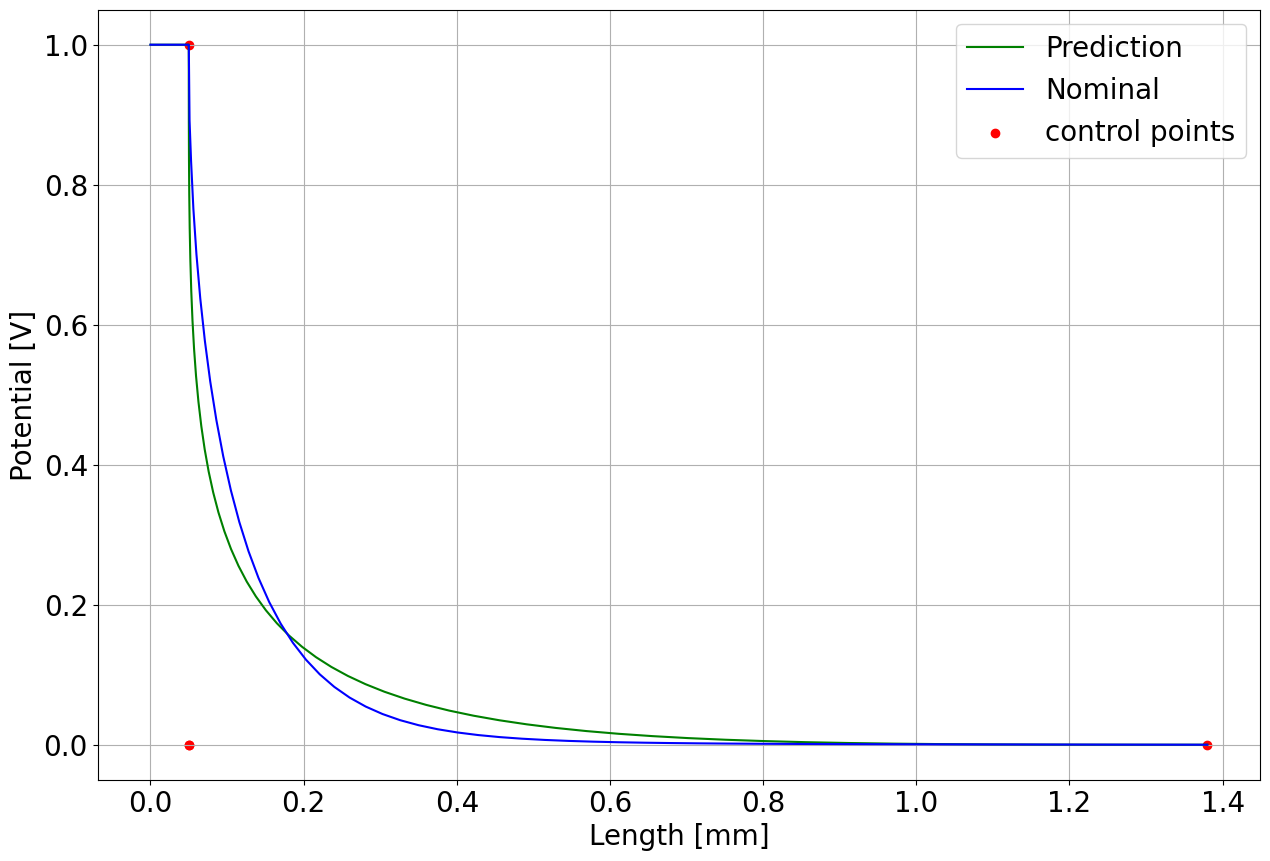

In [7]:
# plot
######################################################################################################
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=1500,num_pts=53)
# obs_space,_ss = env_D.reset()
# action_caseD, _states = model.predict(obs_space)
# action_caseD = np.abs(action_caseD)
g_ptsx,g_ptsy,control_points = env_D.g_points_cubic_bezier(np.array([0,0,0,0]))
# print(f'Montone Decreasing: {env_D.monotonically_decreasing(g_ptsy)}, Convex: {env_D.is_convex(g_ptsy)}')

g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_D.energy(env_D.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_D.energy(env_D.potential_coeff(y_true[2:-1],x_true[2:-1]))
Min_Energy = Energy_pred < Energy_nom

# print(f'Action:{action_caseD}')
print(f'Prediction Energy:{Energy_pred}')
print(f'Nominal Energy:{Energy_nom}')

# Plot 
plt.figure(figsize=(15, 10))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_D.x*1000, env_D.line_threshold, color = 'brown',label='Threshold')
# plt.title(f'Case D er2 = 12.9, SAC Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}, Less Than Nominal:{Min_Energy}')
plt.xlabel('Length [mm]',fontsize=20)
plt.ylabel('Potential [V]',fontsize=20)
# Set axis tick font size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.show()

In [11]:
# SAC_res = {'g_ptsx':g_ptsx,
#            'g_ptsy':g_ptsy
#            }
# (pd.DataFrame(SAC_res)).to_csv('training/cubic_bezier_curve_CaseD_SAC.csv')

### Case L

In [8]:
# hw_micrstr = 0.05e-3
# # read true values 
# df_L = pd.read_csv('NominalGPtsCaseLCase2_1.csv')
# df_L = df_L[df_L['g_ptsx'] >= hw_micrstr]
# df_L = df_L.drop_duplicates(['g_ptsx'])

# x_true = np.array(df_L['g_ptsx']) 
# y_true = np.array(df_L['g_ptsy'])

# x_true = np.insert(x_true,0,0)
# y_true = np.insert(y_true,0,1)
# y_true[-1] = 0

df_D = pd.read_csv('Yamashita_NominalGPtsCaseLCase2_1.csv')

x_true = np.array(df_D['g_ptsx']) 
y_true = np.array(df_D['g_ptsy'])

#### TD3

In [13]:
# env setup
################################################################################################################################################
# setting up the MSA env with number of fs_coeff = 20
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=20,num_pts=10)

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=10)

# model setup
####################################################################################################################################################

# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_L','TD3')
logdir = os.path.join(logdir_root,'Case_L','TD3')
imgdir = os.path.join(imgdir_root,'Case_L','TD3')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[400, 300])

action_noise = OrnsteinUhlenbeckActionNoise(mean=np.zeros(env_L.action_space.shape), sigma=float(0.5) * np.ones(env_L.action_space.shape))
# gamma = 0.98

hyperparams = {
    'gamma': 0.98,
    'buffer_size': 200000, 
    'learning_starts': 1_000,
    'gradient_steps': 1,
    'batch_size': 256,
}

# set the total steps to be taken during model learning
TIMESTEPS = timesteps # one hundred thousand timesteps

model = TD3("MlpPolicy", 
             env_L,  
             verbose=0, 
             action_noise=action_noise,
             policy_kwargs=policy_kwargs,
             tensorboard_log=os.path.join(logdir,'TD3'),
             **hyperparams)


print('training...........')
start_time = time.time()
model.learn(total_timesteps=TIMESTEPS,
            log_interval=4,
            reset_num_timesteps=True, 
            tb_log_name='Case_L',
            progress_bar=True,
            callback=IntermediatePredictionCallback(env_L,5_000,imgdir,x_true,y_true,'Case_L'))
end_time = time.time()

training_time = end_time - start_time
model.save(f"{models_dir}/{'Case_L'}_{'TD3'}_MSAEnv")

Output()

training...........


#### SAC

In [14]:
# setting up the MSA env with number of fs_coeff = 500
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=20,num_pts=10)

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=10)

In [15]:
# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_L','SAC')
logdir = os.path.join(logdir_root,'Case_L','SAC')
imgdir = os.path.join(imgdir_root,'Case_L','SAC')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(log_std_init=-3, net_arch=[400, 300])

hyperparams = {
    'ent_coef': 'auto',  
    'batch_size':256,  
    'buffer_size': 20000,        
    'learning_rate': 0.0007,               
    'gamma': 0.98,      
    'tau':0.02,
    'learning_starts':1000,
    'use_sde':True      
}
1
# set the total steps to be taken during model learning
TIMESTEPS = timesteps # one hundred thousand timesteps

model = SAC("MlpPolicy", 
             env_L,  
             verbose=0, 
             policy_kwargs=policy_kwargs,
             tensorboard_log=os.path.join(logdir,'SAC'),
             **hyperparams)

print('training...........')
start_time = time.time()
model.learn(total_timesteps=TIMESTEPS,
            log_interval=4,
            reset_num_timesteps=True, 
            tb_log_name='Case_L',
            progress_bar=True,
            callback=IntermediatePredictionCallback(env_L,5_000,imgdir,x_true,y_true,'Case_L'))
end_time = time.time()

training_time = end_time - start_time

model.save(f"{models_dir}/{'Case_L'}_{'SAC'}_MSAEnv")

Output()

training...........


Prediction Energy:1.3102336648788825e-11
Nominal Energy:1.1549945548531716e-11


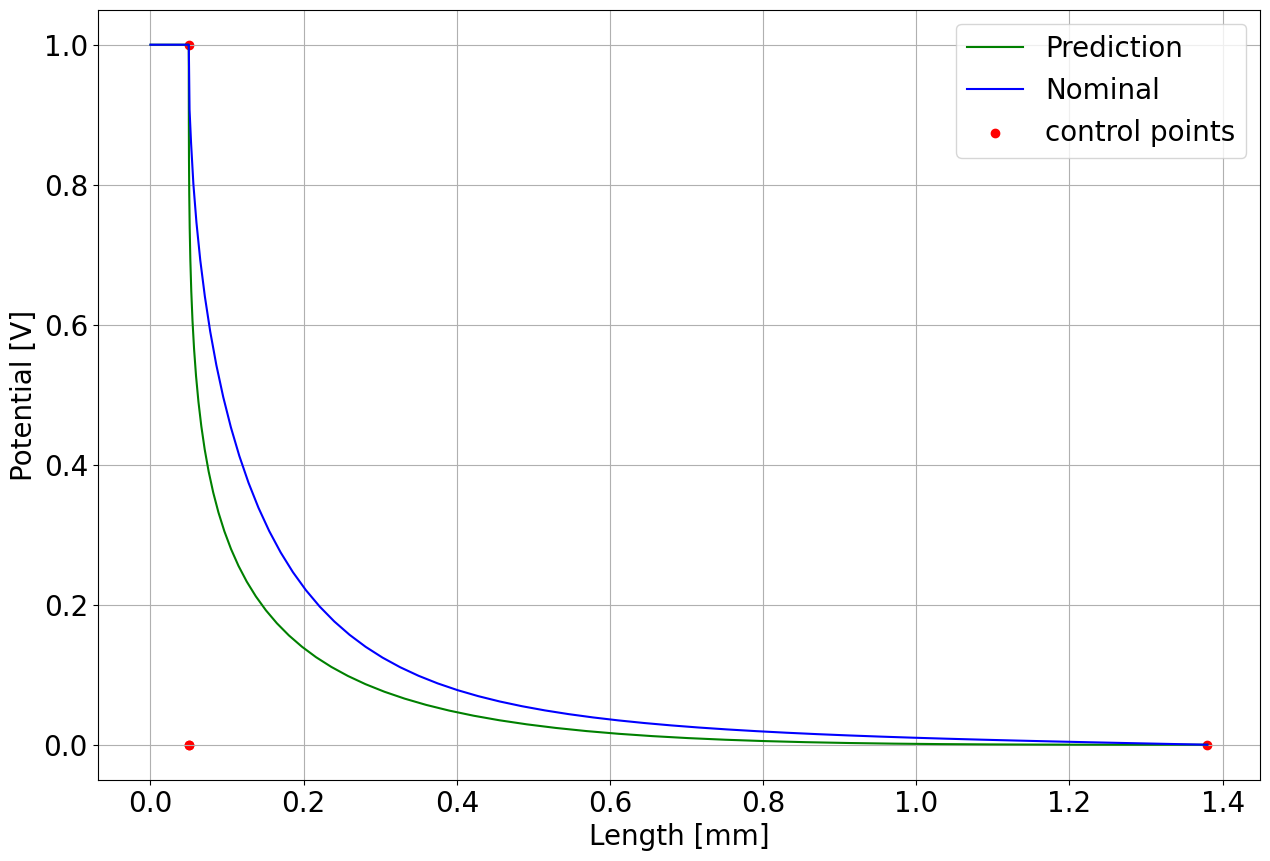

In [9]:
# plot
######################################################################################################
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=1500,num_pts=53)
# obs_space,_ss = env_L.reset()
# action_caseL, _states = model.predict(obs_space)
# action_caseL = np.abs(action_caseL)
g_ptsx,g_ptsy,control_points = env_L.g_points_cubic_bezier(np.array([0,0,0,0]))
# print(f'Montone Decreasing: {env_L.monotonically_decreasing(g_ptsy)}, Convex: {env_L.is_convex(g_ptsy)}')

g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_L.energy(env_L.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_L.energy(env_L.potential_coeff(y_true[2:-1],x_true[2:-1]))
Min_Energy = Energy_pred < Energy_nom

# print(f'Action:{action_caseD}')
print(f'Prediction Energy:{Energy_pred}')
print(f'Nominal Energy:{Energy_nom}')

# Plot 
plt.figure(figsize=(15, 10))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_D.x*1000, env_D.line_threshold, color = 'brown',label='Threshold')
# plt.title(f'Case D er2 = 12.9, SAC Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}, Less Than Nominal:{Min_Energy}')
plt.xlabel('Length [mm]',fontsize=20)
plt.ylabel('Potential [V]',fontsize=20)
# Set axis tick font size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.show()

In [17]:
# SAC_res = {'g_ptsx':g_ptsx,
#            'g_ptsy':g_ptsy
#            }
# (pd.DataFrame(SAC_res)).to_csv('training/cubic_bezier_curve_CaseL_SAC.csv')

### Impedance, Phase Velocity

In [18]:
# c0 = 299792458 # speed of light in vacuum (m/s)

# Zd_pred = 1/(c0*(caseD_res['Capacitance']*caseL_res['Capacitance'])**0.5)
# Zd_nom = 1/(c0*(caseD_res['Capacitance_True']*caseL_res['Capacitance_True'])**0.5)

# Zl_pred = 1/(c0*caseL_res['Capacitance'])
# Zl_nom = 1/(c0*caseL_res['Capacitance_True'])

# eps_eff_pred = caseD_res['Capacitance']/caseL_res['Capacitance']
# eps_eff_nom = caseD_res['Capacitance_True']/caseL_res['Capacitance_True']

# velocity_phase_pred = c0/(eps_eff_pred**0.5)
# velocity_phase_nom = c0/(eps_eff_nom**0.5)

# print(f'''
#       Characteristic Impedance Case D prediction :{Zd_pred}
#       Characteristic Impedance Case D nominal:{Zd_nom}
      
#       Characteristic Impedance Case L prediction :{Zl_pred}
#       Characteristic Impedance Case L nominal :{Zl_nom}
      
#       Effective dielectric constant prediction :{eps_eff_pred}
#       Effective dielectric constant nominal :{eps_eff_nom}
      
#       electron phase velocity pred :{velocity_phase_pred}
#       electron phase velocity nom :{velocity_phase_nom}''')

In [19]:
# Result = {
#     'Zd_pred':Zd_pred,
#     'Zd_nom':Zd_nom,
#     'Zl_pred':Zl_pred,
#     'Zl_nom':Zl_nom,
#     'eps_eff_pred':eps_eff_pred,
#     'eps_eff_nom':eps_eff_nom,
#     'phase_velocity_pred':velocity_phase_pred,
#     'phase_velocity_nom':velocity_phase_nom
# }

# (pd.DataFrame(Result,index=[0])).to_csv('training/cubic_bezier_curve_Impedance_Result.csv', index=False)

# Useful Stuff

In [20]:
# import scipy.io
# mat = scipy.io.loadmat('data22samp.mat')

In [21]:
# import sys
# import traceback

# # number of parallel environments
# num_envs = 4

# def init_env():
#     try:
#         return msaEnv(V0=1, hw_arra=1.38e-3, ht_arra=1.38e-3, ht_subs=0.1382e-3, hw_micrstr=0.05e-3, ht_micrstr=0, er_1=1.0, er_2=12.9, num_fs=20, num_pts=20)
#     except Exception as e:
#         traceback.print_exc(file=sys.stdout)
#         sys.stdout.flush()
#         raise e

# env = SubprocVecEnv([init_env for _ in range(num_envs)])

# import pickle

# def is_picklable(obj):
#     try:
#         pickle.dumps(obj)
#         return True
#     except Exception as e:
#         print(f"Error: {e}")
#         return False

# # Example usage
# class PicklableObject:
#     pass

# # Check picklability of an instance of PicklableObject
# obj = PicklableObject()
# result = is_picklable(obj)
# print(f"Is picklable: {result}")

In [22]:
# %%timeit
# a = [2,5,6,9,8,7,4,10,1,3]

# for i in range(0,len(a)-1):
#     for j in range(0,len(a)-1):
#         if a[j]<=a[j+1]:
#             temp = a[j]
#             a[j] = a[j+1]
#             a[j+1] = temp     
        